# UC salary analysis with polars

A port of `notebook.ipynb` (pandas, 2020 data from JSON files) to
[polars](https://docs.pola.rs/), reading from the SQLite database built by
`build-db.py` and the title categories in `data/title_categories.csv`.

## Data sources & info

Data collected from <https://ucannualwage.ucop.edu/> (see `download-data.ipynb`),
one JSON file per year 2010-2025 in `data/json/`, loaded into
`data/uc_salaries.db` by `python3 build-db.py`. Categories per title come from
`categorize-titles.py` (see `docs/title-categories.md`).

### Pay descriptions

* Gross Pay: base salary + additional pay (summer salary, grants, overtime ...)
* Regular Pay: base salary

**In "Regular Pay" mode rows with Regular Pay == 0 are filtered**, as in the original notebook.

### Why polars

* Expressions instead of index gymnastics: `df.filter(pl.col("x") > 1)` rather than `df.loc[df["x"] > 1]`.
* Lazy execution (`pl.scan_*` / `.lazy()`), query optimisation and multi-threading, so the
  full 4.8M-row table is workable on a laptop.
* No index, no `SettingWithCopyWarning`, strict types, and `null` instead of `NaN`.

### Learning polars

* User guide: <https://docs.pola.rs/> - start with *Concepts* and *Expressions*.
* Coming from pandas: <https://docs.pola.rs/user-guide/migration/pandas/>
* API reference (search `DataFrame`, `Expr`, `LazyFrame`): <https://docs.pola.rs/api/python/stable/reference/>
* Modern Polars (pandas vs polars side by side): <https://kevinheavey.github.io/modern-polars/>
* Polars cookbook / recipes: <https://docs.pola.rs/user-guide/misc/>, <https://github.com/pola-rs/polars/tree/main/docs/source/user-guide>
* Cheat sheet: <https://franzdiebold.github.io/polars-cheat-sheet/Polars_cheat_sheet.pdf>
* SQL on DataFrames: <https://docs.pola.rs/user-guide/sql/intro/>
* Plotting: `df.plot` (Altair) <https://docs.pola.rs/user-guide/misc/visualization/>; matplotlib takes `df["col"].to_numpy()` / `.to_list()`

The pandas equivalent of each step is noted in comments as `# pandas: ...`.

In [1]:
import sqlite3

import polars as pl

# pandas: pd.options.display.float_format = '{:,}'.format
pl.Config.set_tbl_rows(30)
pl.Config.set_fmt_str_lengths(50)
pl.Config.set_float_precision(0)  # pay columns as whole dollars (display only)

USE_GROSS_PAY = False
PAY_COL = "gross_pay" if USE_GROSS_PAY else "regular_pay"
DB = "data/uc_salaries.db"
conn = sqlite3.connect(DB)

## Title categories

The original notebook pulled the Google Sheet with `pd.read_csv(<gviz url>)`.
The categories now live in the repo (`sync-title-sheet.py pull` refreshes them from the sheet).

In [2]:
# pandas: TITLE_CODE_MAP = pd.read_csv(TITLE_CODE_TYPE_SHEET)
# polars infers column types from the first 100 rows by default and errors (rather than
# silently upcasting to object) when a later row does not fit; infer from the whole file.
TITLE_CODE_MAP = pl.read_csv("data/title_categories.csv", infer_schema_length=None)

# pandas: TITLE_CODE_MAP['Category'].unique()
print(TITLE_CODE_MAP["category"].unique().sort().to_list())

# Counts and person-years by category, sorted (pandas: value_counts / groupby().agg())
TITLE_CODE_MAP.group_by("category").agg(
    pl.len().alias("titles"),
    pl.col("n_2025").sum(),
    pl.col("n_all").sum(),
).sort("n_2025", descending=True)

['Academic Administration', 'Academic Research', 'Athletics', 'Health Care (Med Center & Clinical)', 'Lecturers (Unit 18)', 'Non-Senate Faculty', 'Other / Uncategorized', 'Other Academic', 'Senate Faculty', 'Senior Management Group', 'Staff - Management', 'Staff - Professional & Supervisory', 'Staff - Support & Operations', 'Student Instruction', 'Student Research', 'Students']


category,titles,n_2025,n_all
str,u32,i64,i64
"""Health Care (Med Center & Clinical)""",2272,101909,1014003
"""Students""",80,69829,878472
"""Staff - Professional & Supervisory""",2794,58809,804784
"""Staff - Support & Operations""",1190,30614,599015
"""Student Instruction""",63,27320,396890
"""Student Research""",33,16185,218857
"""Senate Faculty""",273,15778,221535
"""Academic Research""",154,15118,230767
"""Non-Senate Faculty""",169,8925,113491


In [3]:
# The 24 Unit 18 titles from the original sheet, and everything now under Lecturers (Unit 18)
# pandas: TITLE_CODE_MAP[TITLE_CODE_MAP['Category'] == 'Unit 18']['Title']
TITLE_CODE_MAP.filter(pl.col("category") == "Lecturers (Unit 18)").select(
    "title", "secondary_category", "original_category", "n_2025", "avg_gross_2025"
).sort("n_2025", descending=True)

title,secondary_category,original_category,n_2025,avg_gross_2025
str,str,str,i64,f64
"""LECT-AY-1/9""","""Lecturer (Pre-Six)""","""Unit 18""",1440,16829
"""LECT-AY""","""Lecturer (Pre-Six)""","""Unit 18""",1263,53524
"""LECT-AY-CONTINUING""","""Lecturer (Continuing)""","""Unit 18""",1199,91752
"""LECT-AY-1/10""","""Lecturer (Pre-Six)""","""Unit 18""",695,12363
"""LECT IN SUMMER SESSION""","""Summer Session Lecturer""","""Unit 18""",507,10569
"""LECT-MISCELLANEOUS/PART TIME""","""Lecturer (misc / part-time / without salary)""","""Non-Senate""",453,1464
"""TEACHER-SPEC PROG""","""Other Unit 18 instructional title (Teacher-Special…","""Unit 18""",298,6893
"""SR LECT-AY-CONTINUING""","""Senior Lecturer (Continuing)""","""Unit 18""",249,128798
"""LECT-FY""","""Lecturer (Pre-Six)""","""Unit 18""",187,30236


## Load DataFrames

`pl.read_database` accepts any DB-API connection, so the SQLite file works directly.
The `salaries_categorized` view already joins `title_categories` onto `salaries`.

In [4]:
COLUMNS = ["year", "location", "first_name", "last_name", "title", "gross_pay", "regular_pay",
           "overtime_pay", "other_pay", "category", "secondary_category", "is_health"]

def load_data_for_year(year: int) -> pl.DataFrame:
    # pandas: json.loads + pd.DataFrame(data, columns=COLUMNS); df = df.loc[df[PAY_COL] > 0]
    df = pl.read_database(
        f"SELECT {', '.join(COLUMNS)} FROM salaries_categorized WHERE year = ?",
        connection=conn, execute_options={"parameters": (year,)},
    )
    if not USE_GROSS_PAY:
        df = df.filter(pl.col(PAY_COL) > 0)
    print(f"Loaded {df.height:,} records for {year}")
    return df

salaries_2020 = load_data_for_year(2020)
salaries_2025 = load_data_for_year(2025)
salaries_2025.head()

Loaded 284,197 records for 2020


Loaded 347,346 records for 2025


year,location,first_name,last_name,title,gross_pay,regular_pay,overtime_pay,other_pay,category,secondary_category,is_health
i64,str,str,str,str,f64,f64,f64,f64,str,str,str
2025,"""ASUCLA""","""*****""","""*****""","""ANL 1""",30012,29754,0,258,"""Staff - Professional & Supervisory""","""Administration, Analysis & Clerical""","""N"""
2025,"""ASUCLA""","""*****""","""*****""","""ANL 1""",38489,36273,0,2216,"""Staff - Professional & Supervisory""","""Administration, Analysis & Clerical""","""N"""
2025,"""ASUCLA""","""*****""","""*****""","""ANL 1""",43554,41862,1693,0,"""Staff - Professional & Supervisory""","""Administration, Analysis & Clerical""","""N"""
2025,"""ASUCLA""","""*****""","""*****""","""ANL 2""",18484,18155,115,214,"""Staff - Professional & Supervisory""","""Administration, Analysis & Clerical""","""N"""
2025,"""ASUCLA""","""*****""","""*****""","""BLANK AST 2 SUPV""",13550,13550,0,0,"""Staff - Professional & Supervisory""","""Administration, Analysis & Clerical""","""N"""


## Titles grouped by function / school

Filters are expressions. `pl.col("category").is_in([...])` replaces
`df['Title'].isin(titles)`; the join to categories is already done by the view.

In [5]:
VALID_CATEGORIES = set(TITLE_CODE_MAP["category"].unique())

def filter_by_school(df: pl.DataFrame, location: str) -> pl.DataFrame:
    # pandas: df.loc[df['Location'] == location]
    return df.filter(pl.col("location") == location)

def titles_in_category(df: pl.DataFrame, category) -> pl.DataFrame:
    """Rows whose title is in one (or a list of) categories; '' or 'All' means no filter."""
    if not category or category == "All":
        return df
    if isinstance(category, str):
        category = [category]
    for c in category:
        assert c in VALID_CATEGORIES, f'"{c}" is not a valid title code category'
    return df.filter(pl.col("category").is_in(category))

def non_health(df: pl.DataFrame) -> pl.DataFrame:
    return df.filter(pl.col("is_health") == "N")

LECT = "Lecturers (Unit 18)"
SENATE = "Senate Faculty"
NON_SENATE = "Non-Senate Faculty"
INSTRUCTIONAL = [SENATE, NON_SENATE, LECT]

lect_salaries_2025 = titles_in_category(salaries_2025, LECT)
all_berkeley_salaries = filter_by_school(salaries_2025, "Berkeley")
berkeley_lect_salaries_2025 = filter_by_school(lect_salaries_2025, "Berkeley")

# pandas: all_berkeley_salaries['Title'].unique().size
all_berkeley_salaries["title"].n_unique()

1138

### Role counts by campus

The pandas version built four `groupby().count()` frames and `reduce`-merged them.
In polars one `group_by` + `pivot` does it.

In [6]:
# Teaching professors are a secondary category of Senate Faculty (the original "Teaching Track")
role = (
    salaries_2025
    .filter(pl.col("category").is_in(INSTRUCTIONAL))
    .with_columns(
        pl.when(pl.col("secondary_category").str.starts_with("Teaching Professor"))
        .then(pl.lit("Teaching Professors"))
        .otherwise(pl.col("category"))
        .alias("role")
    )
)

role_counts = (
    role.group_by("location", "role").agg(pl.len().alias("n"))
    .pivot(on="role", index="location", values="n")
    .fill_null(0)
    .sort("location")
)
role_counts

location,Lecturers (Unit 18),Senate Faculty,Teaching Professors,Non-Senate Faculty
str,u32,u32,u32,u32
"""Berkeley""",1627,1702,53,243
"""Davis""",559,2120,69,846
"""Irvine""",604,1592,112,827
"""Los Angeles""",1327,2586,29,2639
"""Merced""",145,303,49,4
"""Riverside""",309,876,79,112
"""San Diego""",541,1969,168,1362
"""San Francisco""",0,2078,0,2257
"""Santa Barbara""",337,927,86,44


### Distribution of pay by title

`groupby('Title')['Regular Pay'].describe()` becomes an explicit `agg` list.
Quantiles are expressions too, so any column set can be described the same way.

In [7]:
def describe_by(df: pl.DataFrame, by: str, col: str) -> pl.DataFrame:
    """pandas: df.groupby(by)[col].describe()"""
    return (
        df.group_by(by).agg(
            pl.len().alias("count"),
            pl.col(col).mean().alias("mean"),
            pl.col(col).std().alias("std"),
            pl.col(col).min().alias("min"),
            pl.col(col).quantile(0.25).alias("25%"),
            pl.col(col).median().alias("50%"),
            pl.col(col).quantile(0.75).alias("75%"),
            pl.col(col).max().alias("max"),
        )
        .sort("count", descending=True)
    )

describe_by(berkeley_lect_salaries_2025, "title", "regular_pay")

title,count,mean,std,min,25%,50%,75%,max
str,u32,f64,f64,f64,f64,f64,f64,f64
"""LECT-AY-1/10""",554,12406,11238,398,4706,9447,15994,71420
"""LECT-AY""",298,46444,34800,351,20242,40100,72811,195241
"""LECT-AY-CONTINUING""",257,86184,46118,1264,53618,85339,104952,287442
"""TEACHER-SPEC PROG""",190,5271,6425,150,1440,3220,6324,42809
"""LECT-FY""",99,20144,17050,258,9547,16133,25960,117775
"""SR LECT-AY-CONTINUING""",43,121872,53834,9277,98927,122232,140061,287448
"""LECT-AY-1/10-CONTINUING""",31,20646,13020,778,9043,19746,27974,45804
"""PRE-SIX YR APPT-TEMP SUPP-1/10""",27,26575,20392,3796,9125,23501,36240,81769
"""TEACHER-SPEC PROG-CONTINUING""",24,14271,10209,700,7380,11335,19150,34673


In [8]:
# Regular vs gross side by side (pandas: two describes merged on Title, then rename _x/_y)
reg = describe_by(berkeley_lect_salaries_2025, "title", "regular_pay").select(
    "title", "count", pl.col("50%").alias("median regular"), pl.col("mean").alias("mean regular"))
gross = describe_by(berkeley_lect_salaries_2025, "title", "gross_pay").select(
    "title", pl.col("50%").alias("median gross"), pl.col("mean").alias("mean gross"))
reg.join(gross, on="title", how="left").sort("count", descending=True)

title,count,median regular,mean regular,median gross,mean gross
str,u32,f64,f64,f64,f64
"""LECT-AY-1/10""",554,9447,12406,9626,13582
"""LECT-AY""",298,40100,46444,42622,51017
"""LECT-AY-CONTINUING""",257,85339,86184,90531,97545
"""TEACHER-SPEC PROG""",190,3220,5271,3510,5833
"""LECT-FY""",99,16133,20144,17184,22118
"""SR LECT-AY-CONTINUING""",43,122232,121872,129076,130080
"""LECT-AY-1/10-CONTINUING""",31,19746,20646,19746,21763
"""PRE-SIX YR APPT-TEMP SUPP-1/10""",27,23501,26575,24072,30988
"""TEACHER-SPEC PROG-CONTINUING""",24,11335,14271,12505,15035


### Top / bottom slices

`nlargest(n, col)` is `top_k(n, by=col)` (or `sort(col, descending=True).head(n)`).
A share of the rows: `top_k(int(df.height * 0.42), by=PAY_COL)`.

In [9]:
lect_count = berkeley_lect_salaries_2025.height
half = lect_count // 2
top_42_berkeley = berkeley_lect_salaries_2025.top_k(int(lect_count * 0.42), by=PAY_COL)
top_50pct = berkeley_lect_salaries_2025.top_k(half, by=PAY_COL)
bottom_50pct = berkeley_lect_salaries_2025.bottom_k(half, by=PAY_COL)
top_20 = berkeley_lect_salaries_2025.top_k(20, by=PAY_COL)
top_10 = berkeley_lect_salaries_2025.top_k(10, by=PAY_COL)

# pandas: series.describe()
top_42_berkeley[PAY_COL].describe()

statistic,value
str,f64
"""count""",683
"""null_count""",0
"""mean""",73845
"""std""",43821
"""min""",24712
"""25%""",38997
"""50%""",63717
"""75%""",97832
"""max""",287448


### Summary table by group (the `table_data()` of the original)

Each row of the summary is a (description, frame, category filter) triple, exactly as before;
`pl.concat` stacks the per-group summaries.

In [10]:
ADMIN = ["Senior Management Group", "Academic Administration", "Staff - Management"]

def summarize(description, df, categories):
    pay = titles_in_category(df, categories)[PAY_COL]
    return pl.DataFrame({
        "Description": [description],
        "Categories": [", ".join(categories) if isinstance(categories, list) else (categories or "(all)")],
        "Total Salary": [pay.sum()], "Count": [pay.len()], "Mean": [pay.mean()],
        "Min": [pay.min()], "25%": [pay.quantile(0.25)], "50%": [pay.median()],
        "75%": [pay.quantile(0.75)], "Max": [pay.max()],
    })

def table_data(base: pl.DataFrame, lect: pl.DataFrame) -> pl.DataFrame:
    n = lect.height
    rows = [
        ("All", base, ""),
        ("Execs, deans, directors (SMG + academic admin + staff mgmt)", base, ADMIN),
        ("Senior Management Group only", base, "Senior Management Group"),
        ("Head coaches / all athletics", base, "Athletics"),
        ("All instructional titles", base, INSTRUCTIONAL),
        ("Senate Faculty", base, SENATE),
        ("Non-Senate Faculty", base, NON_SENATE),
        ("Unit 18 all", base, LECT),
        ("Unit 18 bottom 50%", lect.bottom_k(n // 2, by=PAY_COL), ""),
        ("Unit 18 top 50%", lect.top_k(n // 2, by=PAY_COL), ""),
        ("Unit 18 top 20", lect.top_k(20, by=PAY_COL), ""),
        ("Unit 18 top 10", lect.top_k(10, by=PAY_COL), ""),
        ("Student instructors", base, "Student Instruction"),
    ]
    return pl.concat([summarize(*r) for r in rows])

print("Berkeley 2025")
table_data(non_health(all_berkeley_salaries), berkeley_lect_salaries_2025)

Berkeley 2025


Description,Categories,Total Salary,Count,Mean,Min,25%,50%,75%,Max
str,str,f64,i64,f64,f64,f64,f64,f64,f64
"""All""","""(all)""",1711791017,34665,49381,5,4153,19200,77024,965909
"""Execs, deans, directors (SMG + academic admin + st…","""Senior Management Group, Academic Administration, …",131249204,682,192448,759,142880,179386,228333,959068
"""Senior Management Group only""","""Senior Management Group""",4855437,13,373495,33532,222917,353323,480445,959068
"""Head coaches / all athletics""","""Athletics""",26749028,286,93528,792,37376,74031,116771,965909
"""All instructional titles""","""Senate Faculty, Non-Senate Faculty, Lecturers (Uni…",407611026,3540,115144,150,17033,92508,180675,570933
"""Senate Faculty""","""Senate Faculty""",336248142,1748,192362,285,134533,178758,253950,570933
"""Non-Senate Faculty""","""Non-Senate Faculty""",12413994,165,75236,2500,30417,52063,111000,314583
"""Unit 18 all""","""Lecturers (Unit 18)""",58948890,1627,36232,150,6206,17276,51833,287448
"""Unit 18 bottom 50%""","""(all)""",5750090,813,7073,150,2961,6204,11112,17262


In [11]:
print("All UC 2025 (health care excluded)")
table_data(non_health(salaries_2025), non_health(lect_salaries_2025))

All UC 2025 (health care excluded)


Description,Categories,Total Salary,Count,Mean,Min,25%,50%,75%,Max
str,str,f64,i64,f64,f64,f64,f64,f64,f64
"""All""","""(all)""",12491561096,234373,53298,1,5275,32734,81638,1325440
"""Execs, deans, directors (SMG + academic admin + st…","""Senior Management Group, Academic Administration, …",1182162496,6197,190764,374,140366,177333,224223,1325440
"""Senior Management Group only""","""Senior Management Group""",66970099,153,437713,33532,332491,404423,480445,1325440
"""Head coaches / all athletics""","""Athletics""",89115719,1121,79497,96,28116,68460,100310,965909
"""All instructional titles""","""Senate Faculty, Non-Senate Faculty, Lecturers (Uni…",2304270866,17987,128108,25,38678,124208,184542,676583
"""Senate Faculty""","""Senate Faculty""",1978119936,10968,180354,25,129067,165225,227225,676583
"""Non-Senate Faculty""","""Non-Senate Faculty""",63486081,1113,57041,29,17091,42117,81684,314583
"""Unit 18 all""","""Lecturers (Unit 18)""",262664849,5906,44474,115,9761,27065,73611,338275
"""Unit 18 bottom 50%""","""(all)""",32809030,2953,11110,115,5631,9761,16000,27062


### Teaching professors: a secondary category

Secondary categories carry the detail (pre-six vs continuing lecturers, teaching professors vs ladder rank).

In [12]:
(
    non_health(salaries_2025)
    .filter(pl.col("category").is_in([SENATE, LECT]))
    .group_by("category", "secondary_category")
    .agg(pl.len().alias("n"), pl.col(PAY_COL).median().alias("median"), pl.col(PAY_COL).sum().alias("total"))
    .sort("category", "n", descending=[False, True])
)

category,secondary_category,n,median,total
str,str,u32,f64,f64
"""Lecturers (Unit 18)""","""Lecturer (Pre-Six)""",3641,16854,104447489
"""Lecturers (Unit 18)""","""Lecturer (Continuing)""",1468,78121,108664462
"""Lecturers (Unit 18)""","""Other Unit 18 instructional title (Teacher-Special…",308,6324,10050829
"""Lecturers (Unit 18)""","""Senior Lecturer (Continuing)""",260,113656,30645367
"""Lecturers (Unit 18)""","""Instructional Assistant (Supv Teacher Ed / Field W…",117,46491,7458517
"""Lecturers (Unit 18)""","""Summer Session Lecturer""",62,9536,853248
"""Lecturers (Unit 18)""","""Lecturer (UC Law SF / Hastings; not Unit 18)""",46,10706,516296
"""Lecturers (Unit 18)""","""Lecturer (misc / part-time / without salary)""",4,4576,28641
"""Senate Faculty""","""Ladder Rank (Professor series)""",9073,176742,1776216603


## Growth over time with the lazy API

Everything so far was eager (`DataFrame`). For all 16 years use a `LazyFrame`:
polars builds a query plan, prunes columns/rows and only computes what is needed
when `.collect()` is called. Aggregate in SQL first so only ~2k rows cross the DB boundary,
then do the reshaping lazily.

In [13]:
yearly = pl.read_database(
    """SELECT year, location, category, secondary_category,
              COUNT(*) AS people, SUM(gross_pay) AS gross_pay
       FROM salaries_categorized WHERE is_health = 'N'
       GROUP BY year, location, category, secondary_category""",
    connection=conn,
).lazy()

def role_expr():
    return (
        pl.when(pl.col("secondary_category").str.starts_with("Teaching Professor")).then(pl.lit("Teaching professors"))
        .when(pl.col("category") == SENATE).then(pl.lit("Senate faculty"))
        .when(pl.col("category") == LECT).then(pl.lit("Lecturers (Unit 18)"))
        .when(pl.col("category").is_in(ADMIN)).then(pl.lit("All admin"))
        .otherwise(None)
        .alias("role")
    )

growth = (
    yearly
    .with_columns(role_expr())
    .drop_nulls("role")
    .filter(pl.col("year") >= 2019)
    .group_by("year", "role").agg(pl.col("people").sum(), pl.col("gross_pay").sum())
    .sort("role", "year")
    # window function: index each role to its first year (pandas: groupby().transform('first'))
    .with_columns(
        (100 * pl.col("people") / pl.col("people").first().over("role")).round(1).alias("people_index"),
        (100 * pl.col("gross_pay") / pl.col("gross_pay").first().over("role")).round(1).alias("pay_index"),
        (pl.col("gross_pay") / pl.col("people")).round(0).alias("pay_per_person"),
    )
)
print(growth.explain())  # the optimised query plan; nothing has run yet

 WITH_COLUMNS:
 [(((100 * col("people")) / col("people").first().over([col("role")]))).round().alias("people_index"), (((100 * col("gross_pay")) / col("gross_pay").first().over([col("role")]))).round().alias("pay_index"), ((col("gross_pay") / col("people").cast(Float64))).round().alias("pay_per_person")] 
  SORT BY [col("role"), col("year")]
    AGGREGATE[maintain_order: false]
      [col("people").sum(), col("gross_pay").sum()] BY [col("year"), col("role")]
      FROM
      FILTER col("role").is_not_null()
      FROM
        simple π 4/4 ["year", "role", "people", ... 1 other column]
           WITH_COLUMNS:
           [when(col("secondary_category").str.starts_with(["Teaching Professor"])).then("Teaching professors").otherwise(when(col("category") == "Senate Faculty").then("Senate faculty").otherwise(when(col("category") == "Lecturers (Unit 18)").then("Lecturers (Unit 18)").otherwise(when(col("category").is_in([["Senior Management Group", "Academic Administration", "Staff - Managemen

In [14]:
growth_df = growth.collect()
growth_df.pivot(on="role", index="year", values="pay_index").sort("year")

year,All admin,Lecturers (Unit 18),Senate faculty,Teaching professors
i64,f64,f64,f64,f64
2019,100,100,100,100
2020,89,97,111,128
2021,86,96,113,151
2022,87,112,117,169
2023,95,110,124,196
2024,102,118,132,230
2025,110,120,138,266


In [15]:
# Same thing for one campus: add a filter before the group_by and collect again
growth_berkeley = (
    yearly.filter(pl.col("location") == "Berkeley")
    .with_columns(role_expr()).drop_nulls("role").filter(pl.col("year") >= 2019)
    .group_by("year", "role").agg(pl.col("people").sum(), pl.col("gross_pay").sum())
    .sort("role", "year")
    .with_columns((100 * pl.col("people") / pl.col("people").first().over("role")).round(1).alias("people_index"))
    .collect()
)
growth_berkeley.pivot(on="role", index="year", values="people_index").sort("year")

year,All admin,Lecturers (Unit 18),Senate faculty,Teaching professors
i64,f64,f64,f64,f64
2019,100,100,100,100
2020,99,98,100,118
2021,100,104,100,154
2022,104,144,101,196
2023,105,104,103,209
2024,108,117,105,236
2025,111,112,106,241


## More polars idioms worth knowing

* `over()` window functions: rank within campus, share of campus payroll.
* `pl.when().then().otherwise()` for conditional columns.
* `str` namespace: `pl.col("title").str.contains("LECT")`.
* `pl.SQLContext` runs SQL against DataFrames.
* `with_columns` adds columns; `select` chooses; both accept many expressions at once.

In [16]:
# All titles containing LECT (the original notebook did this with numpy on unique()).
# pandas: df[df['Title'].str.contains('LECT')]['Title'].unique()
(
    salaries_2025.filter(pl.col("title").str.contains("LECT") & ~pl.col("title").str.contains("ELECT"))
    .group_by("title", "category").agg(pl.len().alias("n"))
    .sort("n", descending=True)
)

title,category,n
str,str,u32
"""LECT-AY-1/9""","""Lecturers (Unit 18)""",1384
"""LECT-AY""","""Lecturers (Unit 18)""",1237
"""LECT-AY-CONTINUING""","""Lecturers (Unit 18)""",1184
"""LECT-AY-1/10""","""Lecturers (Unit 18)""",676
"""SR LECT-AY-CONTINUING""","""Lecturers (Unit 18)""",249
"""LECT-FY""","""Lecturers (Unit 18)""",182
"""LECT-AY-1/9-CONTINUING""","""Lecturers (Unit 18)""",113
"""LECT-FY-CONTINUING""","""Lecturers (Unit 18)""",110
"""LECT IN SUMMER SESSION""","""Lecturers (Unit 18)""",62


In [17]:
# Rank each lecturer within their campus and compute each campus's share of the UC lecturer payroll
(
    non_health(lect_salaries_2025)
    .with_columns(
        pl.col(PAY_COL).rank(method="ordinal", descending=True).over("location").alias("rank_in_campus"),
        (100 * pl.col(PAY_COL).sum().over("location") / pl.col(PAY_COL).sum()).round(1).alias("campus_pct_of_uc_lecturer_pay"),
    )
    .filter(pl.col("rank_in_campus") <= 3)
    .select("location", "rank_in_campus", "title", PAY_COL, "campus_pct_of_uc_lecturer_pay")
    .sort("location", "rank_in_campus")
)

location,rank_in_campus,title,regular_pay,campus_pct_of_uc_lecturer_pay
str,u32,str,f64,f64
"""Berkeley""",1,"""SR LECT-AY-CONTINUING""",287448,22
"""Berkeley""",2,"""LECT-AY-CONTINUING""",287442,22
"""Berkeley""",3,"""LECT-AY-CONTINUING""",287442,22
"""Davis""",1,"""CONTINUING EDUCATOR III""",275889,11
"""Davis""",2,"""SR LECT-AY-CONTINUING""",262988,11
"""Davis""",3,"""LECT-AY-CONTINUING""",232926,11
"""Irvine""",1,"""LECT-AY-CONTINUING""",279374,8
"""Irvine""",2,"""LECT-AY-CONTINUING""",238790,8
"""Irvine""",3,"""SR LECT-AY-CONTINUING""",226076,8


In [18]:
# SQL against DataFrames (handy when a query is easier to say in SQL)
ctx = pl.SQLContext(salaries=salaries_2025, titles=TITLE_CODE_MAP, eager=True)
ctx.execute("""
    SELECT location, COUNT(*) AS lecturers, ROUND(AVG(gross_pay)) AS avg_gross
    FROM salaries
    WHERE category = 'Lecturers (Unit 18)' AND is_health = 'N'
    GROUP BY location ORDER BY lecturers DESC
""")

location,lecturers,avg_gross
str,i64,f64
"""Berkeley""",1627,40147
"""Los Angeles""",1327,44526
"""Irvine""",604,39458
"""Davis""",559,58271
"""San Diego""",541,61122
"""Santa Cruz""",383,51597
"""Santa Barbara""",337,66867
"""Riverside""",309,56446
"""Merced""",145,70833


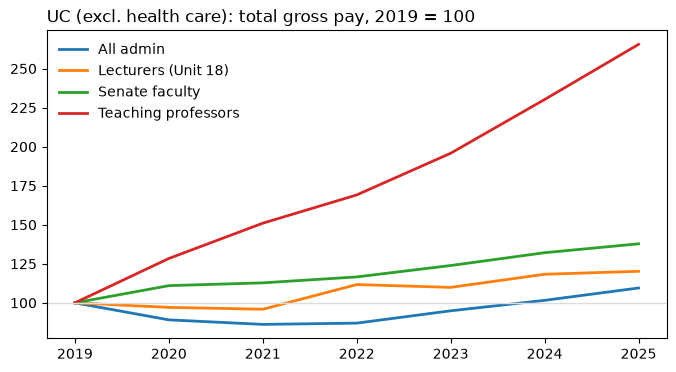

In [19]:
# Quick plot: matplotlib takes lists / numpy from polars columns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
for role, g in growth_df.group_by("role"):
    ax.plot(g["year"].to_list(), g["pay_index"].to_list(), label=role[0], lw=2)
ax.axhline(100, color="#ddd", lw=1)
ax.set_title("UC (excl. health care): total gross pay, 2019 = 100", loc="left")
ax.legend(frameon=False)
plt.show()

In [20]:
# Write results (pandas: df.to_csv). Polars also writes parquet, which keeps types and is much faster to reload.
title_counts = (
    salaries_2025.group_by("title").agg(pl.len().alias("count")).sort("count")
)
title_counts.write_csv("output/uc_title_counts_2025.csv")
growth_df.write_csv("output/growth_polars.csv")
title_counts.tail()

title,count
str,u32
"""TEACHG ASST-GSHIP""",12914
"""STDT 1""",14361
"""STDT 4""",16262
"""STDT 2""",17185
"""CLIN NURSE 2""",17471


## Misc notes

* `LECT-` is a little too specific and `LECT` too general as a title filter; use `category` /
  `secondary_category` from `data/title_categories.csv` instead.
* Rows are payroll rows, not people: someone with two appointments appears twice.
* See `docs/title-categories.md` for the data-quality caveats (2012 title vocabulary change,
  UCPath 2019/2020 reporting change for chairs and directors, 2022 lecturer retro-pay rows).